In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, fft, rfftfreq, fftfreq
# from scipy.signal.windows import hann
from scipy.signal import csd, welch, windows
from scipy.io import loadmat

In [3]:
# Load data from ImpTube12.mat
data = loadmat('ImpTube12.mat')
Mic12 = data['Mic12']
fs = int(data['fs'][0][0])

signal1 = Mic12[:, 0]
signal2 = Mic12[:, 1]

# Define Welch parameters
overlap_factor = 0.5  # 50% overlap

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


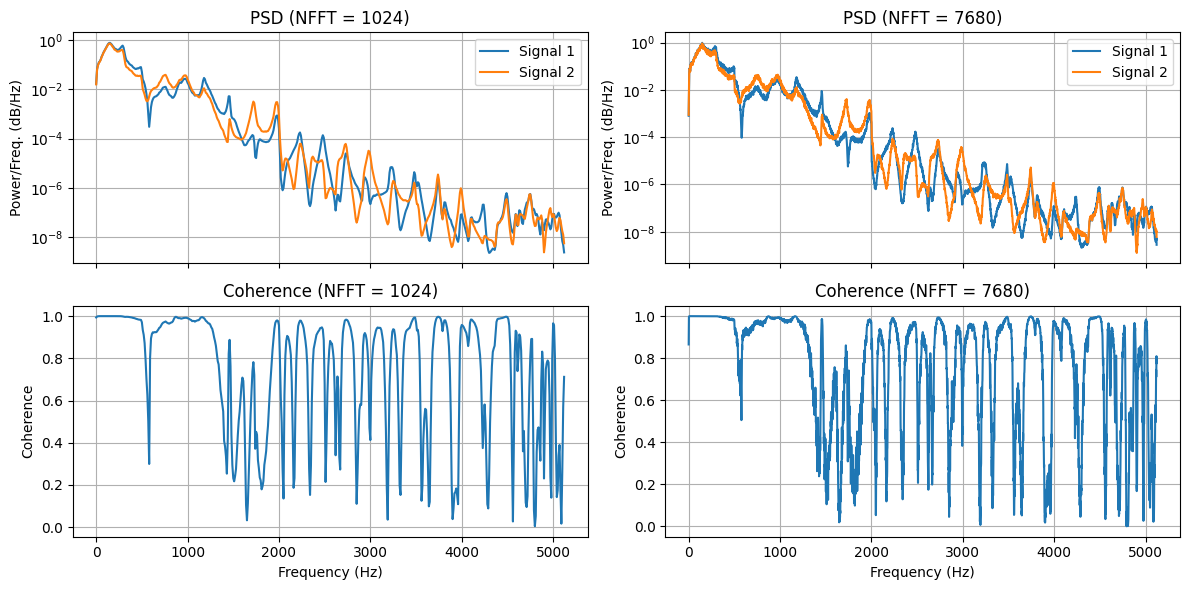

In [11]:
# Calculate and plot PSDs for each signal
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
i = 0
nfft_values = [1024, 7680]

for nfft in nfft_values:

    window = np.hanning(nfft)  # Hanning window
    overlap = int(nfft * overlap_factor)  # 50% overlap
    
    # Compute the Welch PSD
    f, psd1 = welch(signal1, fs=fs, window=window, nperseg=nfft, noverlap=overlap, scaling='density')
    _, psd2 = welch(signal2, fs=fs, window=window, nperseg=nfft, noverlap=overlap, scaling='density')
    f12, S12 = csd(signal1, signal2, fs=fs, window=window, nperseg=nfft, noverlap=overlap)
    
    C_12 = np.abs(S12) ** 2 / (psd1 * psd2)
    
    # Plot PSD
    axs[0, i].semilogy(f, psd1, label=f'Signal 1')
    axs[0, i].semilogy(f, psd2, label=f'Signal 2')
    axs[0, i].set_title(f"PSD (NFFT = {nfft})")
    axs[0, i].set_ylabel("Power/Freq. (dB/Hz)")
    axs[0, i].legend()
    axs[0, i].grid()
    
    
    axs[1, i].plot(f, C_12)
    axs[1, i].set_title(f"Coherence (NFFT = {nfft})")
    axs[1, i].set_xlabel("Frequency (Hz)")
    axs[1, i].set_ylabel("Coherence")
    axs[1, i].grid()
    i += 1

plt.tight_layout()
plt.savefig(f'E4_P1_1.eps', format='eps')  # Save the figure in EPS format
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


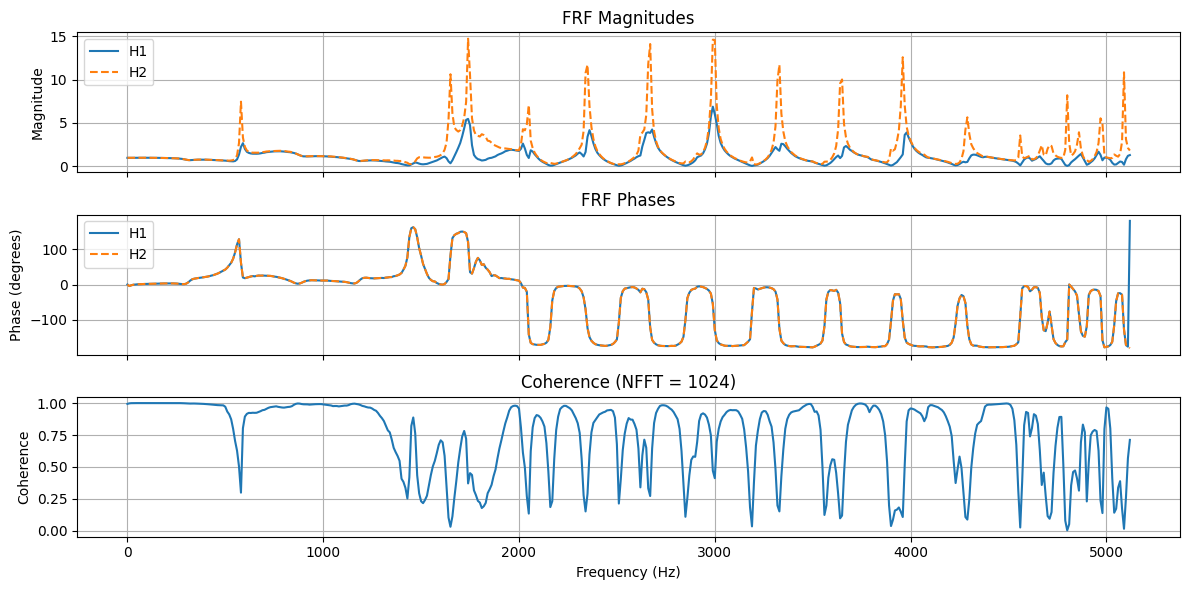

In [21]:
# Define NFFT and calculate PSDs and CPSD
nfft = 1024
window = np.hanning(nfft)  # Hanning window
overlap = int(nfft * overlap_factor)  # 50% overlap

f, psd1 = welch(signal1, fs=fs, window=window, nperseg=nfft, noverlap=overlap, scaling='density')
_, psd2 = welch(signal2, fs=fs, window=window, nperseg=nfft, noverlap=overlap, scaling='density')
_, S12 = csd(signal1, signal2, fs=fs, window=window, nperseg=nfft, noverlap=overlap)

C_12 = np.abs(S12) ** 2 / (psd1 * psd2)

# Compute H1 and H2 estimates
H1 = S12 / psd1  # noise free for noise in Signal 2, underestimate for noise in Signal 1
H2 = psd2 / S12.conj()  # noise free for noise at Signal 1, overestimate with noise at Signal 2

# Compute magnitude and phase
H1_mag = np.abs(H1)
H1_phase = np.angle(H1, deg=True)
H2_mag = np.abs(H2)
H2_phase = np.angle(H2, deg=True)

# Plot Magnitudes
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axs[0].plot(f, H1_mag, label='H1')
axs[0].plot(f, H2_mag, label='H2', linestyle='--')
axs[0].set_title('FRF Magnitudes')
axs[0].set_ylabel('Magnitude')
axs[0].legend()
axs[0].grid(True)

# Plot Phases
axs[1].plot(f, H1_phase, label='H1')
axs[1].plot(f, H2_phase, label='H2', linestyle='--')
axs[1].set_title('FRF Phases')
axs[1].set_ylabel('Phase (degrees)')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(f, C_12)
axs[2].set_title(f"Coherence (NFFT = {nfft})")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Coherence")
axs[2].grid()

plt.tight_layout()
plt.savefig(f'E4_P1_2.eps', format='eps')  # Save the figure in EPS format
plt.show()